## 📦 Cell 1: Importing Libraries

In this cell, we load all the Python libraries we'll need throughout the workflow. Think of this as gathering your tools before starting a project.

Here's what each library does:

- **`numpy`** – The foundational numerical computing library in Python. We use it for array math and data manipulation.
- **`xarray`** – Designed for working with multi-dimensional labeled arrays (think: datasets with dimensions like `lat`, `lon`, `time`). It's the go-to tool for climate and satellite data.
- **`matplotlib.pyplot`** – Python's standard plotting library. We use it to visualize maps and data.
- **`matplotlib.animation`** – A submodule of matplotlib specifically for creating animations. We use `FuncAnimation` from this module to build our SST timelapse GIF by updating a plot frame-by-frame.
- **`geopandas`** – Extends `pandas` to handle geospatial vector data (points, lines, polygons). It reads shapefiles and performs spatial operations.
- **`earthaccess`** – A NASA-developed library that makes it easy to search, authenticate, and stream data directly from NASA's cloud (Earthdata Cloud) without downloading large files first.
- **`pathlib.Path`** – A clean, object-oriented way to handle file system paths that works on any operating system.
- **`rioxarray`** – Extends `xarray` with geospatial (raster I/O) capabilities, including CRS management and spatial clipping. The `rio` accessor is added to xarray datasets when this is imported.
- **`contextily`** – Fetches and renders web map tile basemaps (e.g., Esri, OpenStreetMap) and adds them to matplotlib figures. Used to provide geographic context when visualizing our study area boundary.
- **`IPython.display.Image` and `display`** – Tools built into the Jupyter/IPython environment that allow us to render files — like our saved GIF — directly inside the notebook without opening an external application.

> **Key Concept:** Modern Earth observation workflows are moving toward *cloud-native* approaches — instead of downloading terabytes of satellite data locally, we stream only what we need directly from the cloud. These libraries make that possible.

> **Why Import `matplotlib.pyplot` Once?** You'll notice `matplotlib.pyplot` appears twice in the original code across different cells. In practice, you only need to import it once — consolidating all imports into a single cell at the top of your notebook is a best practice that keeps your workflow clean, readable, and easy to debug.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import geopandas as gpd
import earthaccess as ea
from pathlib import Path
import rioxarray
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display

## 🗂️ Cell 2: Setting Up the Output Directory & SST Variable Name

Here we define two things needed throughout the notebook:

1. **`output_folder`** — a `Path` object pointing to `./outputs/`, which is immediately created if it doesn't already exist (using `mkdir` with `parents=True, exist_ok=True` to avoid errors on repeat runs).
2. **`SST`** — a Python string holding the name of the Sea Surface Temperature variable as it appears inside the dataset: `"analysed_sst"`.

**Why do this here?**

Defining these at the top of the notebook keeps configuration centralized. If the output directory or variable name ever needs to change, there's a single place to update rather than hunting through every cell. The `exist_ok=True` flag also makes the notebook safe to re-run without throwing errors if the folder already exists.

> **Best Practice:** Declaring paths and named constants early — before any data loading or processing — is a standard software engineering habit that improves readability, reduces bugs, and makes notebooks easier to share and reproduce across different environments.

In [2]:
output_folder = Path("./outputs")
output_folder.mkdir(parents=True, exist_ok=True)

SST = "analysed_sst"

## 🗺️ Cell 3: Loading the Study Area Shapefile

This cell loads our geographic **region of interest (ROI)** — the Caribbean study area — from a **shapefile** (`.shp`).

**What's happening step by step:**

- **`Path(".\Shape_Files\Caribbean_Study_Area.shp")`** – Constructs the file path to the shapefile in an OS-safe way.
- **`gpd.read_file(shp_path)`** – Reads the shapefile into a **GeoDataFrame** (`gdf`), which is like a regular pandas DataFrame but with a special `geometry` column containing spatial shapes (polygons in this case).
- **`gdf.crs`** – Prints the **Coordinate Reference System (CRS)** of the shapefile. We want this to be `EPSG:4326` (geographic coordinates: latitude/longitude in degrees), which is standard for global datasets.

> **Key Concept — CRS:** A Coordinate Reference System defines *how* coordinates map to real locations on Earth. `EPSG:4326` (also called WGS84) uses degrees of latitude and longitude and is the most common system for global datasets. Mismatched CRSs between layers are one of the most common sources of error in GIS work.

In [3]:
shp_path = Path(".\Shape_Files\Caribbean_Study_Area.shp")

gdf = gpd.read_file(shp_path)

print("CRS:", gdf.crs)          # should be EPSG:4326
gdf.head()

CRS: EPSG:4326


<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\thatg\AppData\Local\Temp\ipykernel_46272\4067487056.py:1: SyntaxWarning: invalid escape sequence '\S'
  shp_path = Path(".\Shape_Files\Caribbean_Study_Area.shp")


,Shape_Leng,Shape_Area,geometry
0,91.734851,135.936349,"MULTIPOLYGON (((-78.49585 21.27354, -78.49699 ..."


## 🗺️ Cell 4: Visualizing the Study Area with a Basemap

This cell plots our shapefile boundary on top of a real-world basemap so we can visually confirm our study area looks correct.

**Key steps:**

- **`gdf.to_crs(epsg=3857)`** – Reprojects the GeoDataFrame to **Web Mercator (EPSG:3857)**. This is required because `contextily` basemaps are served in Web Mercator. Always match projections before overlaying layers!
- **`caribbean_web.plot(...)`** – Draws the polygon outline on the map. `facecolor="none"` makes the interior transparent so we can see the basemap underneath.
- **`ctx.add_basemap(...)`** – Fetches and overlays a tile-based basemap (Esri's World Topo Map) from the internet. This provides geographic context (coastlines, place names, etc.).

> **Why This Matters:** Before downloading any satellite data, it's critical to visually verify that your study area boundary is correctly placed. A shapefile that looks correct on paper might be shifted, too large, or in the wrong projection — catching this early saves a lot of debugging later.

C:\Users\thatg\AppData\Local\Temp\ipykernel_46272\1143580071.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\thatg\AppData\Local\Temp\ipykernel_46272\1143580071.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


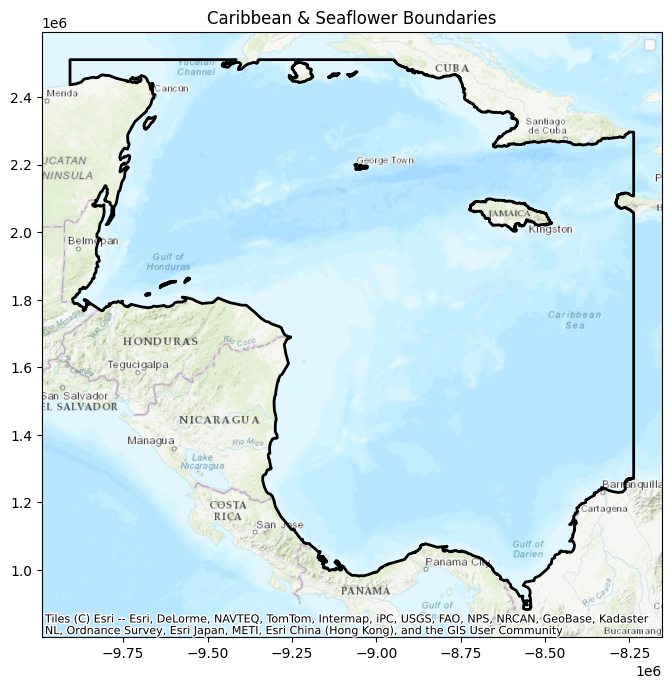

In [4]:
caribbean_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8,8))

caribbean_web.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2,
    linestyle="solid",
    label="Caribbean Study Area"
)

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldTopoMap
)

ax.legend()
plt.title("Caribbean & Seaflower Boundaries")
plt.show()


## 🔐 Cell 5: Authenticating with NASA Earthdata

Before we can access NASA's cloud-hosted satellite data, we need to log in.

- **`ea.login(persist=False)`** – Authenticates your NASA Earthdata account. The `persist=False` argument means your credentials are used for this session only and are **not** saved to a local file — you will need to re-enter them each time you run the notebook.

**What you'll need:**
You must have a free [NASA Earthdata account](https://urs.earthdata.nasa.gov/). The first time you run this, `earthaccess` will prompt you for your username and password.

> **Key Concept — Cloud-Hosted Data:** NASA stores petabytes of satellite data on Amazon Web Services (AWS). Instead of downloading entire files, we authenticate once and then stream only the spatial/temporal subset we need directly from the cloud. This is the modern, scalable approach to large Earth observation datasets.

In [5]:
auth = ea.login(persist=False)

## 📋 Cell 6: Defining the Data Search Parameters

Here we set the parameters that tell `earthaccess` *what* data we want and *where/when*.

- **`SHORT_NAME = "OSTIA-UKMO-L4-GLOB-v2.0"`** – The official NASA dataset identifier for the **OSTIA (Operational Sea Surface Temperature and Sea Ice Analysis)** product, produced by the **UK Met Office (UKMO)**. It is a daily, 0.05° (~5 km) resolution global SST analysis product that blends data from multiple satellite sensors and in-situ observations to produce a gap-free, cloud-corrected SST field.
- **`TEMPORAL_RANGE`** – The date range of interest: all of 2024.
- **`gdf.total_bounds`** – Returns the bounding box of our shapefile as `(minx, miny, maxx, maxy)` — the smallest rectangle that contains the entire study area polygon.
- **`BBOX`** – This bounding box is used to spatially filter search results so we only retrieve granules that overlap our Caribbean study area.

> **Key Concept — Granules:** In NASA terminology, a *granule* is a single file unit of a dataset — typically one day of global coverage for a daily product. Searching by bounding box and date range returns only the granules that intersect our area and time period, avoiding unnecessary downloads.

In [6]:
SHORT_NAME = "OSTIA-UKMO-L4-GLOB-v2.0"
TEMPORAL_RANGE = ("2025-01-01", "2025-12-31")

minx, miny, maxx, maxy = gdf.total_bounds
BBOX = (minx, miny, maxx, maxy)

print("Bounding Box Coordinates:")
print(f"BBOX = ({minx}, {miny}, {maxx}, {maxy})")

Bounding Box Coordinates:
BBOX = (-88.99999999999994, 7.900673528000027, -73.99999999999994, 22.000000000000057)


## ☁️ Cell 7: Searching, Opening, and Loading Data from the Cloud

This is the core cloud data access step — we search for matching granules, open them as file-like objects, and load them into a single `xarray` Dataset.

**Step by step:**

- **`ea.search_data(...)`** – Queries the NASA CMR (Common Metadata Repository) catalog for granules matching our dataset name, bounding box, and temporal range. `count=60` limits results to 60 granules (roughly 2 months if retrieving daily data — adjust as needed for a full year).
- **`ea.open(results)`** – Opens the matching cloud files using `fsspec`, a library that creates Python file-like objects pointing to remote cloud storage — no full download needed.
- **`xr.open_mfdataset(...)`** – Reads *multiple* files simultaneously and combines them into a single `xarray` Dataset.
  - `combine="by_coords"` – Tells xarray to align files along their coordinate values (e.g., stacking daily files along the `time` dimension).
  - `decode_timedelta=True` – Ensures time-related variables are correctly interpreted.

> **Key Concept — Lazy Loading:** `xarray` uses *lazy evaluation* — the data isn't actually read into memory until you explicitly request it (e.g., for a plot or computation). This makes it possible to work with datasets far larger than your RAM.

In [7]:
results = ea.search_data(
    short_name=SHORT_NAME,
    cloud_hosted=True,
    bounding_box=BBOX,
    temporal=TEMPORAL_RANGE,
    count=60
)
if not results:
    raise SystemExit("No granules found. Expand dates or bbox.")

ofiles = ea.open(results)

ds = xr.open_mfdataset(
    ofiles,
    combine="by_coords",
    decode_timedelta=True
)

QUEUEING TASKS | :   0%|          | 0/60 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/60 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/60 [00:00<?, ?it/s]

## 🌡️ Cell 8: Converting Temperature from Kelvin to Celsius

Raw satellite SST data is stored in **Kelvin (K)** — the SI unit for thermodynamic temperature. Scientists and most end-users, however, prefer **Celsius (°C)**.

The conversion is simple: **°C = K − 273.15**

- **`ds[SST] - 273.15`** – Subtracts 273.15 from every SST value in the dataset (across all times, latitudes, and longitudes simultaneously — thanks to xarray's vectorized operations).
- **`ds[SST].attrs["units"] = "Celsius"`** – Updates the metadata attribute stored with the variable so it correctly reflects the new units. Keeping metadata accurate is essential for reproducible science.

> **Why This Matters:** Always check the units of your data before analysis. Using Kelvin values in a "Celsius" context (e.g., computing anomalies, plotting color scales, comparing to in-situ data) would produce completely wrong results. Unit awareness is a fundamental data quality step.

In [8]:
ds[SST] = ds[SST] - 273.15
ds[SST].attrs["units"] = "Celsius"

## 🔍 Cell 9: Inspecting the Dataset

Simply calling `ds` in a Jupyter Notebook displays an interactive summary of the `xarray` Dataset.

**What to look for:**

- **Dimensions** – What axes does the data have? (e.g., `time`, `lat`, `lon`) and how many steps in each?
- **Coordinates** – The actual coordinate values (e.g., date range, lat/lon extent).
- **Data variables** – What variables are stored (e.g., `analysed_sst`, `analysis_error`)?
- **Attributes** – Metadata like source, institution, and processing level.

> **Best Practice:** Always inspect your dataset immediately after loading it. Confirm the dimensions, coordinate ranges, and variable names match your expectations before doing any analysis. This is the data science equivalent of "measure twice, cut once."

In [9]:
ds

<xarray.Dataset> Size: 25GB
Dimensions:           (time: 60, lat: 3600, lon: 7200)
Coordinates:
  * time              (time) datetime64[ns] 480B 2024-12-31T12:00:00 ... 2025...
  * lat               (lat) float32 14kB -89.97 -89.93 -89.88 ... 89.93 89.97
  * lon               (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
Data variables:
    analysed_sst      (time, lat, lon) float32 6GB dask.array<chunksize=(1, 1200, 2400), meta=np.ndarray>
    analysis_error    (time, lat, lon) float32 6GB dask.array<chunksize=(1, 1200, 2400), meta=np.ndarray>
    sea_ice_fraction  (time, lat, lon) float32 6GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    mask              (time, lat, lon) float32 6GB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
Attributes: (12/47)
    Conventions:                CF-1.4, ACDD-1.3
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    summary:                    A merged, multi-sensor L4 Foundation SST product
    references:                 Good S, Fiedler E, Mao C, Martin MJ, Maycock ...
    institution:                UKMO
    history:                    Created from sst.nc; obs_anal.nc; seaice.nc
    ...                         ...
    project:                    Group for High Resolution Sea Surface Tempera...
    publisher_name:             GHRSST Project Office
    publisher_url:              http://www.ghrsst.org
    publisher_email:            ghrsst-po@nceo.ac.uk
    processing_level:           L4
    cdm_data_type:              grid

## ✂️ Cell 10: Assigning a CRS and Clipping to the Study Area

Now we clip the global dataset down to just our Caribbean polygon. This is one of the most important steps in a regional Earth observation workflow.

**Step by step:**

- **`ds.rio.write_crs("EPSG:4326")`** – Explicitly assigns the CRS to the dataset using `rioxarray`. Even though the data is in lat/lon, we need to formally declare this so spatial operations work correctly.
- **`ds.rio.clip(...)`** – Masks the dataset to only the area covered by our shapefile polygon.
  - **`gdf.geometry`** – The polygon(s) to clip to.
  - **`gdf.crs`** – The CRS of the polygon (must match the dataset CRS).
  - **`drop=True`** – Removes the rows and columns that fall entirely outside the polygon, reducing the data size.
  - **`invert=False`** – Keeps data *inside* the polygon (set to `True` to keep data *outside*).

> **Key Concept — Spatial Clipping:** Clipping reduces both memory usage and processing time by discarding irrelevant data. It also ensures that any statistics or visualizations you generate are specific to your study region and not contaminated by surrounding areas.

In [10]:
ds = ds.rio.write_crs("EPSG:4326")

ds_clip = ds.rio.clip(
    gdf.geometry,
    gdf.crs,
    drop=True,        # removes data outside polygon
    invert=False
)

## 🔍 Cell 11: Inspecting the Clipped Dataset

Again, we call `ds_clip` to display the updated dataset summary.

**What to verify here:**

- The `lat` and `lon` dimensions should now be smaller than the original global dataset — confirming the clip worked.
- The data variables and time dimension should be unchanged.

> **Tip:** Compare the latitude/longitude ranges in `ds_clip` against your original bounding box (`BBOX`) to confirm spatial subsetting was successful. This quick sanity check helps catch silent errors where the clip had no effect (e.g., due to a CRS mismatch).

In [11]:
ds_clip

<xarray.Dataset> Size: 81MB
Dimensions:           (time: 60, lat: 282, lon: 300)
Coordinates:
  * time              (time) datetime64[ns] 480B 2024-12-31T12:00:00 ... 2025...
  * lat               (lat) float32 1kB 7.925 7.975 8.025 ... 21.88 21.92 21.98
  * lon               (lon) float32 1kB -88.97 -88.93 -88.88 ... -74.07 -74.03
    spatial_ref       int64 8B 0
Data variables:
    analysed_sst      (time, lat, lon) float32 20MB dask.array<chunksize=(1, 282, 300), meta=np.ndarray>
    analysis_error    (time, lat, lon) float32 20MB dask.array<chunksize=(1, 282, 300), meta=np.ndarray>
    sea_ice_fraction  (time, lat, lon) float32 20MB dask.array<chunksize=(1, 282, 300), meta=np.ndarray>
    mask              (time, lat, lon) float32 20MB dask.array<chunksize=(1, 282, 300), meta=np.ndarray>
Attributes: (12/47)
    Conventions:                CF-1.4, ACDD-1.3
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    summary:                    A merged, multi-sensor L4 Foundation SST product
    references:                 Good S, Fiedler E, Mao C, Martin MJ, Maycock ...
    institution:                UKMO
    history:                    Created from sst.nc; obs_anal.nc; seaice.nc
    ...                         ...
    project:                    Group for High Resolution Sea Surface Tempera...
    publisher_name:             GHRSST Project Office
    publisher_url:              http://www.ghrsst.org
    publisher_email:            ghrsst-po@nceo.ac.uk
    processing_level:           L4
    cdm_data_type:              grid

## 💾 Cell 12: Saving the Clipped Dataset to a NetCDF File

The final step is saving our processed, clipped, and unit-converted dataset to disk as a **NetCDF** file for future use.

**Step by step:**

- **`Path("./class_outputs/...")`** – Defines the output file path.
- **`ds_clip.sortby("time")`** – Ensures the time dimension is in chronological order before saving. Cloud files don't always come back in order.
- **`ds_out.to_netcdf(out_path, engine="netcdf4")`** – Writes the dataset to disk in **NetCDF4 format**, the standard file format for gridded scientific data in Earth sciences.

> **Key Concept — NetCDF:** Network Common Data Form (NetCDF) is a self-describing, machine-independent file format designed for array-oriented scientific data. It stores data *and* metadata (coordinates, units, attributes) together in one file, making it highly portable and reproducible across tools and languages (Python, R, MATLAB, QGIS all support it).

> **Why This Matters:** Saving the processed data locally means you only need to run the expensive cloud-download and processing steps once. Future analyses can load the compact, pre-clipped NetCDF file instantly — a major time saver.

In [12]:
out_path = Path("./outputs/SST_Data.nc")

ds_out = ds_clip.sortby("time") if "time" in ds.coords else ds

ds_out.to_netcdf(out_path, engine="netcdf4")
print("Saved:", out_path)

Saved: outputs\SST_Data.nc


## 🔄 Cell 13: Reloading the Saved Dataset from Disk

After saving our processed dataset to a NetCDF file in the previous step, we now reload it from disk to verify the save was successful and to use this local file as our working dataset going forward.

**Step by step:**

- **`xr.open_mfdataset(...)`** – Opens one or more NetCDF files into a single `xarray` Dataset. Even though we only have one file here, using `open_mfdataset` (instead of `open_dataset`) is a good habit because it scales easily if you later split data across multiple files.
- **`out_path`** – The file path we defined and saved to in the previous cell.
- **`combine="by_coords"`** – Tells xarray to align and merge files based on their coordinate values (e.g., `time`, `lat`, `lon`). For a single file this has no effect, but it's important for consistency if multiple files are ever passed.
- **`decode_timedelta=True`** – Ensures that any time-offset variables are correctly decoded into Python `timedelta` objects rather than raw numbers.
- **`compat='no_conflicts'`** – When combining multiple datasets, this setting requires that any variables shared between files have identical values where they overlap. It's a safety check that prevents silent data corruption during merges.
- **`engine='h5netcdf'`** – Specifies which backend library to use for reading the NetCDF file. `h5netcdf` is a lightweight, Python-native HDF5/NetCDF4 reader that works well with `xarray` and doesn't require the full NetCDF-C library to be installed.

**Why reload at all?**

Reloading from the saved file is an important **validation step**. It confirms that:
1. The file was written to disk without corruption.
2. The dimensions, coordinates, and variables survived the save/load round-trip intact.
3. From this point forward, the workflow is fully reproducible — anyone can start here by loading the pre-processed file, without re-running the cloud download.

Calling `ds_saved` at the end displays the interactive dataset summary in Jupyter so you can visually confirm everything looks correct.

> **Key Concept — Reproducible Checkpoints:** Saving and reloading processed data at key stages of a workflow is a best practice in data science. It creates *checkpoints* that separate expensive steps (cloud access, clipping, unit conversion) from downstream analysis. If something goes wrong later, you can restart from the checkpoint rather than rerunning everything from scratch.

> **`h5netcdf` vs `netcdf4`:** Both engines read the same NetCDF4 file format. `netcdf4` relies on the compiled NetCDF-C library, while `h5netcdf` reads the underlying HDF5 structure directly in pure Python. Either works here — just be consistent between your write and read engines to avoid compatibility issues.

In [13]:
ds_saved = xr.open_mfdataset(
                out_path,
                combine="by_coords",
                decode_timedelta=True,
                compat='no_conflicts',
                engine='h5netcdf'
            )

ds_saved

<xarray.Dataset> Size: 81MB
Dimensions:           (time: 60, lat: 282, lon: 300)
Coordinates:
  * time              (time) datetime64[ns] 480B 2024-12-31T12:00:00 ... 2025...
  * lat               (lat) float32 1kB 7.925 7.975 8.025 ... 21.88 21.92 21.98
  * lon               (lon) float32 1kB -88.97 -88.93 -88.88 ... -74.07 -74.03
Data variables:
    spatial_ref       int64 8B ...
    analysed_sst      (time, lat, lon) float32 20MB dask.array<chunksize=(60, 282, 300), meta=np.ndarray>
    analysis_error    (time, lat, lon) float32 20MB dask.array<chunksize=(60, 282, 300), meta=np.ndarray>
    sea_ice_fraction  (time, lat, lon) float32 20MB dask.array<chunksize=(60, 282, 300), meta=np.ndarray>
    mask              (time, lat, lon) float32 20MB dask.array<chunksize=(60, 282, 300), meta=np.ndarray>
Attributes: (12/47)
    Conventions:                CF-1.4, ACDD-1.3
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    summary:                    A merged, multi-sensor L4 Foundation SST product
    references:                 Good S, Fiedler E, Mao C, Martin MJ, Maycock ...
    institution:                UKMO
    history:                    Created from sst.nc; obs_anal.nc; seaice.nc
    ...                         ...
    project:                    Group for High Resolution Sea Surface Tempera...
    publisher_name:             GHRSST Project Office
    publisher_url:              http://www.ghrsst.org
    publisher_email:            ghrsst-po@nceo.ac.uk
    processing_level:           L4
    cdm_data_type:              grid

## 📅 Cell 14: Resampling the Dataset to Weekly Averages

This single line of code reduces our dataset from **daily** SST values to **weekly** averages. This is a very common operation in time series analysis and Earth observation workflows.

**Breaking it down:**

- **`.resample(time="1W")`** – Groups the data along the `time` dimension into consecutive 1-week bins. Think of it like a temporal version of `groupby` — it chunks the time axis into weekly intervals and prepares them for aggregation.
- **`.mean()`** – Computes the average SST value within each weekly bin, across all pixels independently. Every `(lat, lon)` location gets one averaged value per week instead of seven daily values.

**The result:** `ds_weekly` has the same spatial dimensions (`lat`, `lon`) as `ds_saved`, but its `time` dimension is ~52 steps long (one per week) instead of ~365 (one per day).

---

**Other Time Intervals You Can Use**

The `resample` frequency string is highly flexible. Here are common options you might use depending on your analysis goals:

| Frequency String | Meaning | Example Use Case |
|---|---|---|
| `"1D"` | Daily (no change here) | Fine-scale event tracking |
| `"1W"` | Weekly | Smoothing noise, seasonal trends |
| `"2W"` | Bi-weekly | Intermediate smoothing |
| `"1MS"` | Monthly (start of month) | Climatology, seasonal cycles |
| `"QS"` | Quarterly (seasonal) | El Niño / La Niña analysis |
| `"1YS"` | Yearly | Long-term trend analysis |

For example, to get **monthly** averages instead:
```python
ds_monthly = ds_saved.resample(time="1MS").mean()
```

And you can swap `.mean()` for other aggregations too:
- `.max()` – Maximum SST in each bin (e.g., detecting marine heatwave peaks)
- `.min()` – Minimum SST (e.g., coldest point in a week)
- `.std()` – Standard deviation (e.g., measuring variability within each period)

---

> **Key Concept — Temporal Resampling:** Daily satellite data contains a lot of short-term variability — day-to-day fluctuations driven by weather, clouds, and sensor noise. Resampling to coarser time intervals *smooths out this noise* and makes longer-term trends (seasonal warming, annual cycles) much easier to see and analyze.

> **Why This Matters:** Choosing the right temporal resolution is a tradeoff. Finer resolution (daily) preserves short-term events like storm-driven cooling but is noisier and produces larger files. Coarser resolution (monthly, seasonal) is cleaner and more compact but can miss brief but important events like marine heatwaves. Always match your temporal resolution to the scientific question you're asking.

In [14]:
ds_weekly = ds_saved.resample(time="1W").mean()

## 🎬 Cell 15: Creating an Animated SST Timelapse GIF from Weekly Data

This cell builds an animated GIF that loops through every **weekly time step** in our resampled dataset, showing how Sea Surface Temperature across the Caribbean evolves across 2024. Because we are using `ds_weekly` instead of the raw daily dataset, each frame now represents a **7-day average** rather than a single day — producing a smoother, cleaner animation with ~52 frames instead of ~365.

**Setup — Defining Parameters:**

- **`time_dim = "time"`** – Stores the name of the time dimension as a variable. This makes the code easy to adapt if the dimension name differs in another dataset.
- **`output_path`** – The file path where the finished GIF will be saved.
- **`sst = ds_weekly[SST]`** – Extracts the SST variable from our **weekly-averaged** dataset as a `DataArray` with dimensions `(time, lat, lon)`, where the `time` axis now has ~52 steps (one per week) rather than ~365.

**Setting a Consistent Color Scale:**

- **`vmin = float(sst.min())`** and **`vmax = float(sst.max())`** – Compute the global minimum and maximum SST values across *all* weekly time steps and all locations.

> **Why This Matters:** Fixing `vmin` and `vmax` to the dataset-wide range ensures every frame uses the same color scale. This makes it possible to visually compare temperatures across weeks — if the scale shifted frame-to-frame, warmer and cooler seasons would look identical and the animation would be meaningless.

> **Note — Weekly vs. Daily Range:** Because weekly averaging smooths out extreme single-day values, `vmin` and `vmax` here will be slightly narrower than they would be for the raw daily data. This is expected and actually desirable — it means the color scale is better tuned to the real seasonal signal rather than short-lived spikes.

**Building the First Frame:**

- **`fig, ax = plt.subplots(...)`** – Creates the matplotlib figure and axes the animation will draw on.
- **`sst.isel({time_dim: 0})`** – Selects the **first weekly time step** using integer-based indexing (`isel` = index-select), giving a 2D `(lat, lon)` slice to initialize the plot.
- **`ax.pcolormesh(...)`** – Plots the 2D SST grid as a colored mesh.
  - **`frame0.lon`, `frame0.lat`** – The x and y coordinates of each grid cell.
  - **`frame0.values`** – The raw numpy array of SST values for that week.
  - **`cmap="RdYlBu_r"`** – A diverging colormap: blue = cold, yellow = intermediate, red = warm. The `_r` suffix reverses it so red = hot, which is intuitive for temperature.
  - **`shading="auto"`** – Handles edge alignment between cell coordinates and values automatically.
- **`plt.colorbar(...)`** – Adds a color legend so viewers can read actual temperature values off the map.

> **Key Concept — `pcolormesh`:** Unlike `imshow`, which assumes a regular pixel grid, `pcolormesh` explicitly uses the lat/lon coordinate arrays to position each cell. This is important for geospatial data where grid spacing may not be perfectly uniform.

**The `update()` Function — Heart of the Animation:**

- This is a **callback function** that matplotlib calls once per frame. It receives `i` (the frame index) and updates the plot in place without redrawing the entire figure.
- **`sst.isel({time_dim: i})`** – Selects the i-th weekly slice.
- **`im.set_array(frame.values.ravel())`** – Updates the color mesh with the new weekly SST values. `.ravel()` flattens the 2D array to 1D, which is what `pcolormesh` expects when updating.
- **`str(sst[time_dim].values[i])[:19]`** – Extracts the timestamp for week `i` and trims it to `YYYY-MM-DD HH:MM:SS` format for the title. For weekly data, this timestamp marks the **start of each weekly bin**.
- **`return im, title`** – Returns the updated artists; required when `blit=True`.

**Running the Animation:**

- **`animation.FuncAnimation(...)`** – Drives the animation by repeatedly calling `update(i)` for each frame.
  - **`frames=sst.sizes[time_dim]`** – Automatically sets the number of frames to however many weekly time steps are in `ds_weekly` (~52 for a full year).
  - **`interval=200`** – Time between frames in milliseconds (200 ms = 5 frames per second). With ~52 frames this produces roughly a 10-second loop — you can slow it down (e.g., `interval=400`) to give viewers more time to read each weekly frame.
  - **`blit=True`** – Only redraws the parts of the figure that changed between frames, making rendering significantly faster.

**Saving and Displaying:**

- **`ani.save(output_path, writer="pillow", dpi=120)`** – Renders and saves the animation as a GIF using the **Pillow** image library. `dpi=120` controls the resolution of each frame.
- **`plt.close()`** – Closes the matplotlib figure to free memory.
- **`display(Image(output_path))`** – Renders the saved GIF directly inside the Jupyter Notebook for immediate inspection.

> **Key Concept — Why Weekly Data Makes a Better Animation:** Daily satellite SST data contains short-term noise from weather events, transient cloud cover gaps, and day-to-day variability. Animating raw daily data can feel "flickery" and make it hard to see the underlying seasonal trend. Weekly averages smooth this noise while still capturing meaningful temporal change — making the seasonal warming and cooling cycle much easier to see and communicate.

> **Why This Matters — Science Communication:** Animated GIFs are easy to share in presentations, reports, and on social media. Using weekly-averaged data strikes a good balance: the animation is short enough to be digestible (~52 frames), smooth enough to look professional, and scientifically meaningful enough to reveal real seasonal SST patterns in the Caribbean.

Saved → ./outputs/sst_timelapse.gif


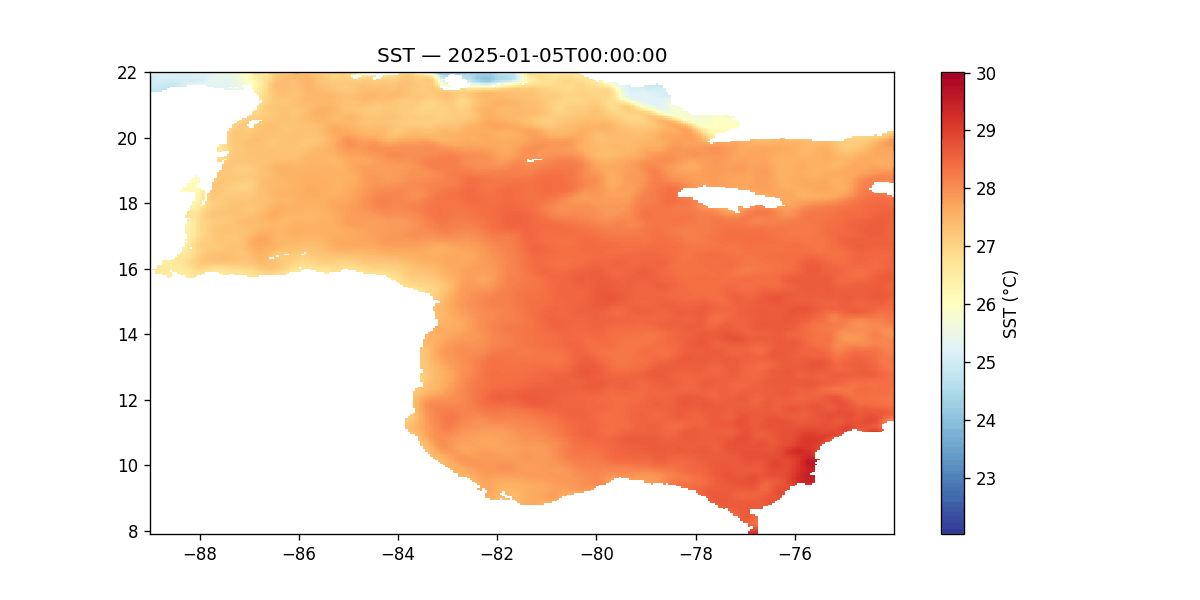

In [15]:
time_dim = "time"     
output_path = "./outputs/sst_timelapse.gif"

sst = ds_weekly[SST]

vmin = float(sst.min())
vmax = float(sst.max())

fig, ax = plt.subplots(figsize=(10, 5))

frame0 = sst.isel({time_dim: 0})
im = ax.pcolormesh(
    frame0.lon, frame0.lat, frame0.values,
    cmap="RdYlBu_r", vmin=vmin, vmax=vmax, shading="auto"
)
plt.colorbar(im, ax=ax, label="SST (°C)")
title = ax.set_title("")

def update(i):
    frame = sst.isel({time_dim: i})
    im.set_array(frame.values.ravel())
    time_val = str(sst[time_dim].values[i])[:19] 
    title.set_text(f"SST — {time_val}")
    return im, title

ani = animation.FuncAnimation(
    fig,
    update,
    frames=sst.sizes[time_dim],
    interval=200,
    blit=True
)

ani.save(output_path, writer="pillow", dpi=120)
plt.close()
print(f"Saved → {output_path}")
display(Image(output_path))

## 📈 Cell 16: Plotting a Time Series of Mean Sea Surface Temperature

This cell computes the **spatial average** of SST across the entire Caribbean study area and plots it as a time series — reducing our full 3D dataset (`lat × lon × time`) down to a simple 1D line showing how the regional average temperature changes over time.

**Step by step:**

- **`ds_saved[SST].mean(dim=["lat", "lon"])`** – Computes the mean SST value across *all* latitude and longitude points simultaneously, for each time step independently. The result is a 1D `DataArray` with only a `time` dimension — one average temperature value per time step.
- **`plt.plot(sst_mean.time, sst_mean, linewidth=2)`** – Plots the time series with time on the x-axis and average SST (°C) on the y-axis.
- **`plt.grid(True)`** – Adds a background grid to make it easier to read values off the plot.
- **`plt.tight_layout()`** – Automatically adjusts spacing so axis labels and titles don't overlap or get cut off.

> **Key Concept — Spatial Aggregation:** Our dataset has three dimensions: `lat`, `lon`, and `time`. By averaging over `lat` and `lon` together, we *collapse* the spatial dimensions entirely, leaving only the temporal signal. This is called a **spatial average** or **area mean**, and it's one of the most fundamental operations in climate science — it tells us how an entire region is behaving as a single system rather than pixel by pixel.

> **Key Concept — Identifying Seasonal Cycles:** A time series like this is one of the first plots you should make with any new climate dataset. For Caribbean SST, you would expect to see a clear **seasonal cycle** — cooler temperatures in winter (January–March) and warmer temperatures in summer (July–September) — driven by changes in solar radiation angle and intensity throughout the year. Any deviations from this expected pattern (e.g., an unusually warm spring) are worth investigating further.

> **Why This Matters:** Maps and animations show *where* temperatures are high or low, but a time series shows *when* and *by how much* things change. Together, spatial maps and temporal plots give you a much more complete understanding of your data than either alone.

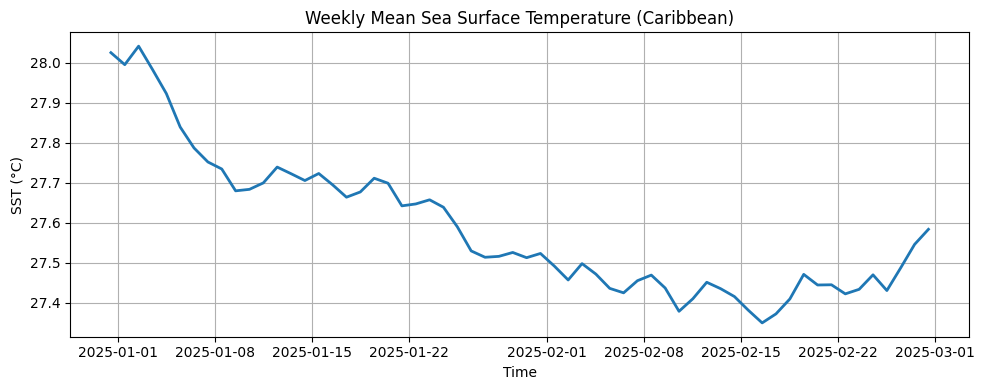

In [16]:
sst_mean = ds_saved[SST].mean(dim=["lat", "lon"])

plt.figure(figsize=(10,4))
plt.plot(sst_mean.time, sst_mean, linewidth=2)
plt.title("Weekly Mean Sea Surface Temperature (Caribbean)")
plt.xlabel("Time")
plt.ylabel("SST (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


## 🔢 Cell 17: Computing Summary Statistics for the SST Time Series

After visualizing the time series, this cell quantifies it — extracting four key **descriptive statistics** that summarize the overall temperature behavior of the Caribbean study area across 2024.

**Step by step:**

- **`sst_mean.mean()`** – The **annual mean SST**: the average of all weekly/daily spatial averages across the entire year. This gives a single representative temperature for the Caribbean in 2024.
- **`sst_mean.max()`** – The **annual maximum SST**: the warmest spatially-averaged value recorded across any single time step. This typically corresponds to the peak of summer warming.
- **`sst_mean.min()`** – The **annual minimum SST**: the coldest spatially-averaged value, typically occurring in late winter.
- **`sst_mean.std()`** – The **standard deviation**: measures how much the SST fluctuates around the annual mean. A larger value means more variability across the year (stronger seasonal cycle); a smaller value means relatively stable temperatures year-round.
- **`float(...)`** – Converts each xarray scalar result to a plain Python float so it can be formatted cleanly in the print statements.
- **`:.2f`** – A Python f-string format specifier that rounds each number to 2 decimal places for clean, readable output.

> **Key Concept — Descriptive Statistics:** These four numbers — mean, max, min, and standard deviation — are the foundation of any quantitative data summary. Together they tell you the *central tendency* (mean), the *range* (max and min), and the *spread* (standard deviation) of your variable. In climate science, these are often the first numbers reported when characterizing a region's temperature regime.

> **Key Concept — Standard Deviation in Climate Context:** A high standard deviation in SST tells you the region experiences strong seasonal swings — large differences between winter and summer. A low standard deviation suggests a more thermally stable environment, like deep tropical waters that don't vary much year-round. For the Caribbean, you would typically expect a moderate standard deviation reflecting a clear but not extreme seasonal cycle.

> **Why This Matters:** Visualizations are powerful, but numbers are what go into reports, papers, and dashboards. Being able to extract and communicate precise summary statistics from a large multidimensional dataset — in just a few lines of code — is a core data science skill. These values also serve as useful sanity checks: if your mean SST comes out at 5°C or 45°C for the Caribbean, something has gone wrong upstream.

In [17]:
mean_temp = float(sst_mean.mean())
max_temp = float(sst_mean.max())
min_temp = float(sst_mean.min())
std_temp = float(sst_mean.std())

print(f"Mean SST (2024): {mean_temp:.2f} °C")
print(f"Max SST (2024): {max_temp:.2f} °C")
print(f"Min SST (2024): {min_temp:.2f} °C")
print(f"Standard Deviation: {std_temp:.2f} °C")


Mean SST (2024): 27.59 °C
Max SST (2024): 28.04 °C
Min SST (2024): 27.35 °C
Standard Deviation: 0.17 °C
